In [132]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [133]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_rows_cleaned.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_cleaned.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

              STATION  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
0                         0.0            160.00  1941     12    1     0   
1                         0.0            160.

In [134]:
# read in station names CSV in order to change from station codes to station names
path = 'E:/Central Valley Fog/station_names.csv'
if os.path.exists(path):
    station_names = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/station_names.csv'
    station_names = pd.read_csv(path, low_memory = False)

print(station_names)

     STATION_ID                                     STATION  BEGIN_DATE  \
0   USW00023155                              BAKERSFIELD AP  1927-12-31   
1   USW00093216                                   BEALE AFB  1959-06-30   
2   USI0000KC83                                       BYRON  2017-08-30   
3   USL000CQUC1                                   CARQUINEZ  2016-02-23   
4   USW00023203                                  CASTLE AFB  1941-12-31   
5   USW00093203                    CHICO ARMY FLYING SCHOOL  1942-05-05   
6   USW00023254                      CONCORD BUCHANAN FIELD  1968-12-31   
7   USL000DPXC1                   DAVIS POINT SAN PABLO BAY  2011-09-09   
8   USI0000KDLO                                 DELANO MUNI  2017-01-05   
9   USW00053125                                      FRESNO  1892-12-31   
10  USW00023167                 FRESNO CHANDLER DOWNTOWN AP  1933-04-30   
11  USW00093193                        FRESNO YOSEMITE INTL  1941-12-03   
12  USM00074917          

In [135]:
# change station ID to station name in CV_rows
station_id_to_name = station_names.set_index('STATION_ID')['STATION']

CV_rows = CV_rows.rename(columns={'STATION': 'STATION_ID'})
CV_rows['STATION'] = CV_rows['STATION_ID'].map(station_id_to_name).fillna(CV_rows['STATION_ID'])

# check:
print(CV_rows[['STATION_ID', 'STATION']].head())

    STATION_ID      STATION
0  USM00074917  GARDNER AAF
1  USM00074917  GARDNER AAF
2  USM00074917  GARDNER AAF
3  USM00074917  GARDNER AAF
4  USM00074917  GARDNER AAF


In [163]:
# remove rows where HourlyVisibility is zero or missing
CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

#fill in nan values in HourlyVisibility with 0
#CV_rows['HourlyVisibility'] = CV_rows['HourlyVisibility'].fillna(0)

print("CV_rows:", CV_rows.shape)

CV_rows: (10739952, 12)


In [165]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 100.000)
]

print("CV_fog_rows:", CV_fog_rows.shape) 

CV_fog_rows: (10199169, 12)


In [166]:
#counting days measured per year per station
fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        97
1  BAKERSFIELD AP  1929       269
2  BAKERSFIELD AP  1930        94
3  BAKERSFIELD AP  1931       254
4  BAKERSFIELD AP  1932       366


In [167]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


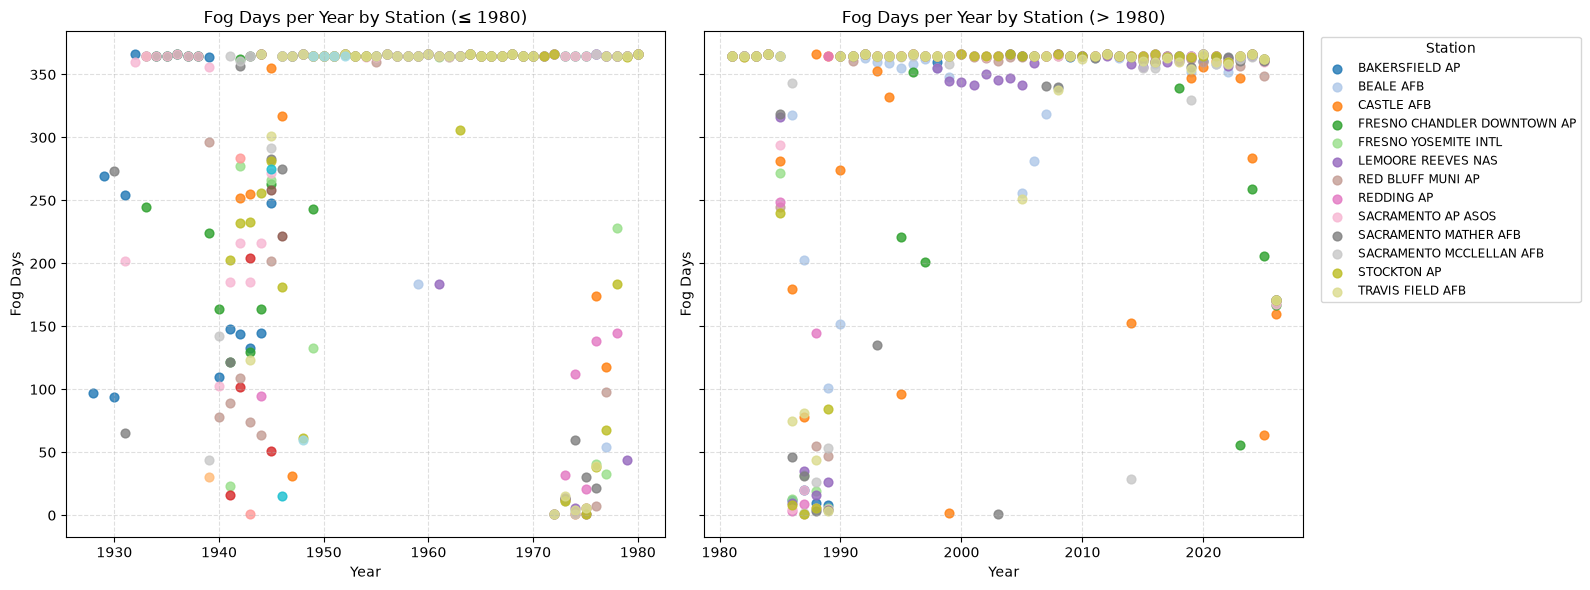

In [168]:
# plot the 'fog' days per year for the outliers for each station
# doing this in order to see where outlier years are
plot_stations = [st for st in stations_pre1970 if st in fog_days_year['STATION'].unique()]
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
color_map = dict(zip(plot_stations, colors))

# Make sure to only plot for stations with data back to at least 1970
fog_pre1970 = fog_days_year[fog_days_year['STATION'].isin(plot_stations)]

# Create a scatter plot for fog days per year for each station
# Data is separated into two subplots: one for years ≤ 1980 and another for years > 1980.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plot_stations:
    station_df = fog_pre1970[fog_pre1970['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Fog Days per Year by Station (≤ 1980)')
axes[1].set_title('Fog Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

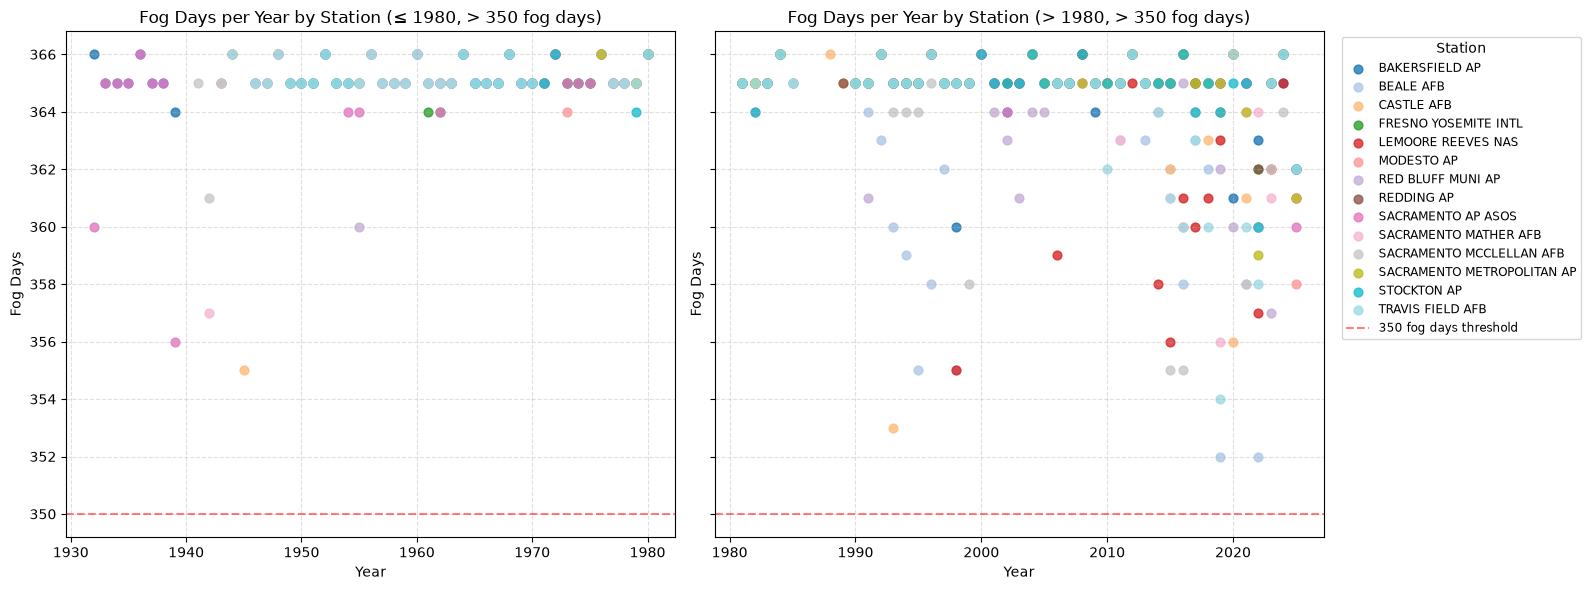

Stations with > 350 fog days: 14
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO YOSEMITE INTL', 'LEMOORE REEVES NAS', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'SACRAMENTO METROPOLITAN AP', 'STOCKTON AP', 'TRAVIS FIELD AFB']


In [207]:
# Remove stations with less than or only 350 fog days counted
fog_days_year_filtered = fog_days_year[fog_days_year['fog_days'] > 350]

# Get the filtered list of stations
filtered_plot_stations = [st for st in plot_stations if st in fog_days_year_filtered['STATION'].unique()]

# Create color map for filtered stations
colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# Filter fog data for pre-1970 stations with > 350 fog days
fog_pre1970_filtered = fog_days_year_filtered[fog_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in filtered_plot_stations:
    station_df = fog_pre1970_filtered[fog_pre1970_filtered['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Fog Days per Year by Station (≤ 1980, > 350 fog days)')
axes[1].set_title('Fog Days per Year by Station (> 1980, > 350 fog days)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=350, color='red', linestyle='--', alpha=0.5, label='350 fog days threshold')

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

print(f"Stations with > 350 fog days: {len(filtered_plot_stations)}")
print(filtered_plot_stations)

In [225]:
# Remove stations with 350 or fewer fog days counted
fog_days_year_no_outliers = fog_days_year[fog_days_year["fog_days"] > 350].copy()

# Get the valid station-year combinations for merging
valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_fog_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 1003
CV_fog_rows_no_outliers: (9296767, 12)


In [281]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]
print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows.shape)
# low_vis_rows.head()

CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (188026, 12)


In [282]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [283]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (808, 3)


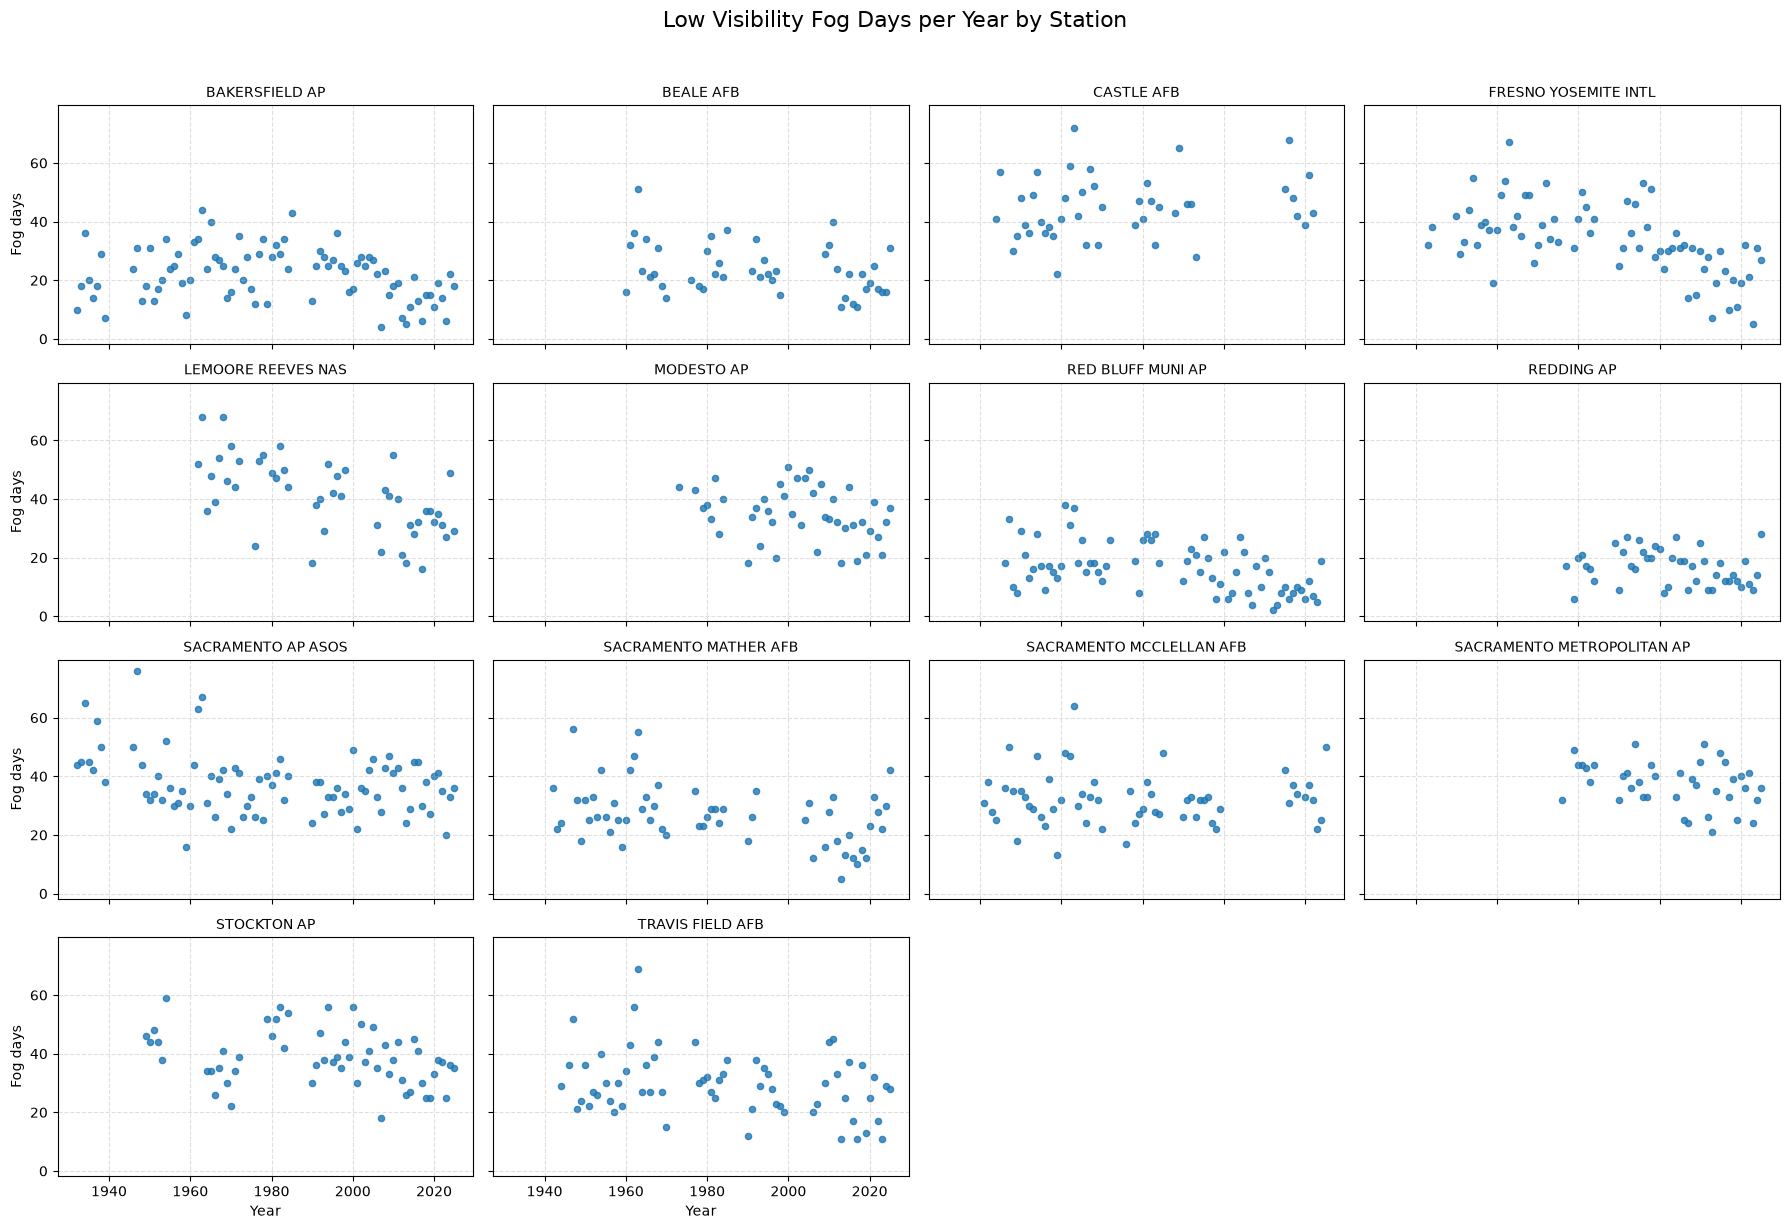

In [284]:
# plot the fog days per year for the filtered stations
stations = low_vis_fog_days_year_filtered['STATION'].unique()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [285]:
# trend_stats_low_vis = []

# for station, station_df in low_vis_fog_days_year.groupby("STATION"):
#     station_df = station_df.sort_values("year")
#     if len(station_df) < 3:
#         continue

#     model = smf.ols("fog_days ~ year", data=station_df).fit()

#     trend_stats_low_vis.append({
#         "STATION": station,
#         "n_obs": len(station_df),
#         "min_year": station_df["year"].min(),
#         "max_year": station_df["year"].max(),
#         "slope": model.params["year"],
#         "intercept": model.params["Intercept"],
#         "r_squared": model.rsquared,
#         "p_value": model.pvalues["year"],
#         "slope_se": model.bse["year"],
#         "trend_significant": model.pvalues["year"] < 0.05,
#     })

# trend_stats_low_vis = pd.DataFrame(trend_stats_low_vis).sort_values("p_value")

# print("Low-visibility fog-day trend statistics by station:")
# print(trend_stats_low_vis[
#     ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
# ].head(20))

# significant_low_vis = trend_stats_low_vis[trend_stats_low_vis["trend_significant"]]
# print(f"\nStations with significant low-visibility fog-day trends: {len(significant_low_vis)}")
# print(significant_low_vis[
#     ["STATION", "n_obs", "slope", "p_value", "r_squared"]
# ])

# annual_low_vis = (
#     low_vis_fog_days_year
#     .groupby("year", as_index=False)["fog_days"]
#     .sum()
# )

# model_annual_low_vis = smf.ols("fog_days ~ year", data=annual_low_vis).fit()

# print("\nAnnual aggregated low-visibility fog-day trend summary:")
# print(model_annual_low_vis.summary())

In [286]:
# Filter for low visibility fog days after 1980
post1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] >= 1980].copy()

trend_stats_low_vis_post1980 = []

for station, station_df in post1980_low_vis.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_post1980 = pd.DataFrame(trend_stats_low_vis_post1980).sort_values("p_value")

print("Post-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_post1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_post1980 = trend_stats_low_vis_post1980[trend_stats_low_vis_post1980["trend_significant"]]
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980)}")
print(significant_low_vis_post1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_post1980 = (
    post1980_low_vis
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_post1980 = smf.ols("fog_days ~ year", data=annual_low_vis_post1980).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
0               BAKERSFIELD AP     42      1980      2025 -0.461675  0.078275   
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.621237  0.105596   
6            RED BLUFF MUNI AP     40      1980      2024 -0.399624  0.075793   
12                 STOCKTON AP     41      1980      2025 -0.395599  0.096472   
4           LEMOORE REEVES NAS     34      1980      2025 -0.377893  0.121682   
1                    BEALE AFB     31      1980      2025 -0.207025  0.086407   
7                   REDDING AP     42      1980      2025 -0.136367  0.068051   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.177202  0.089240   
5                   MODESTO AP     41      1980      2025 -0.152616  0.110207   
13            TRAVIS FIELD AFB     35      1980      2025 -0.137820  0.108514   
9        SACRAMENTO MATHER AFB     28      1980

In [297]:
stations_significant_low_vis_post1980 = significant_low_vis_post1980.loc[
    significant_low_vis_post1980["trend_significant"], "STATION"
].tolist()

# stations_significant_events_post1980 = trend_events_post1980.loc[
#     trend_events_post1980["trend_significant"], "STATION"
# ].tolist()

# stations_significant_post1980 = sorted(
#     set(stations_significant_low_vis_post1980 + stations_significant_events_post1980)
# )

print("Significant post-1980 low-visibility fog-day trend stations:")
print(stations_significant_low_vis_post1980)
# print("\nSignificant post-1980 monthly-event trend stations:")
# print(stations_significant_events_post1980)
# print("\nUnion of significant post-1980 stations:")
# print(stations_significant_post1980)

Significant post-1980 low-visibility fog-day trend stations:
['BAKERSFIELD AP', 'FRESNO YOSEMITE INTL', 'RED BLUFF MUNI AP', 'STOCKTON AP', 'LEMOORE REEVES NAS', 'BEALE AFB']


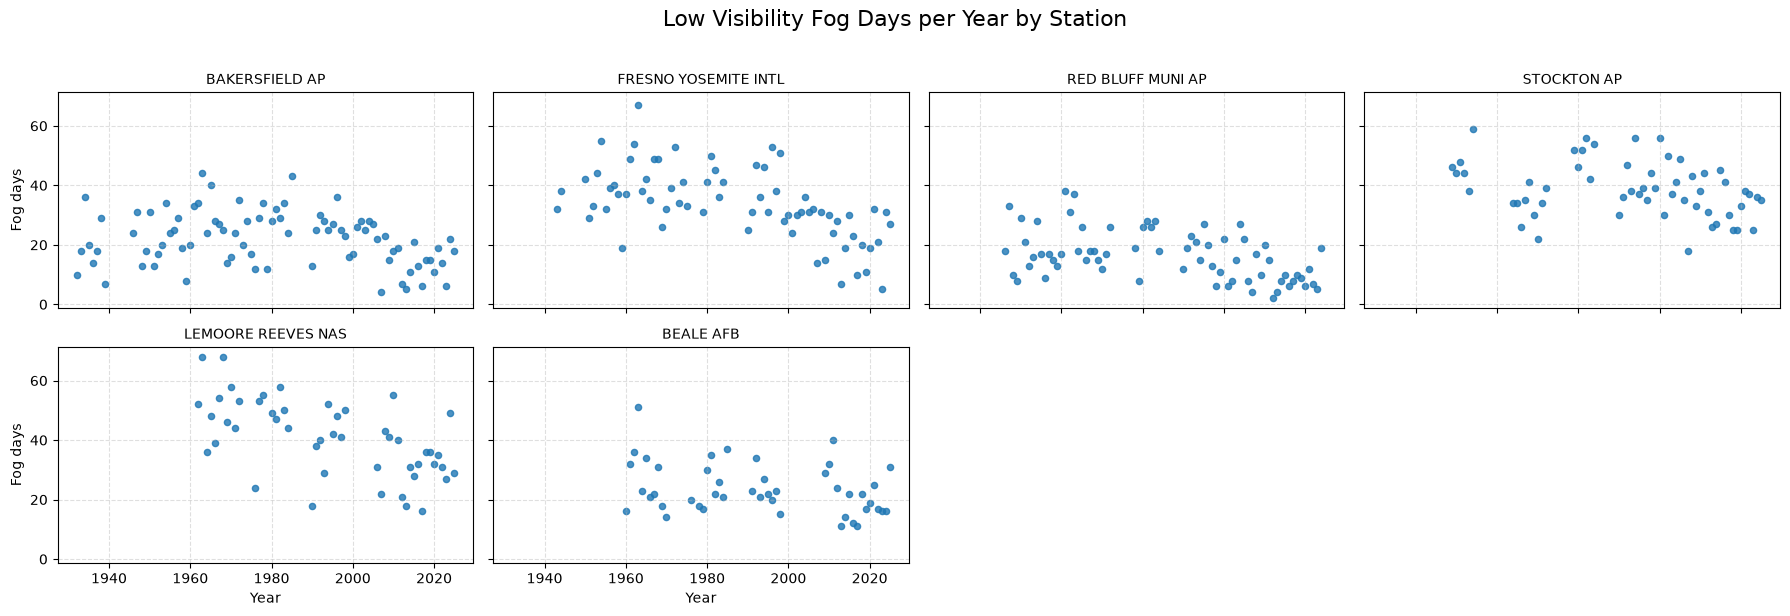

In [ ]:
stations = stations_significant_low_vis_post1980
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

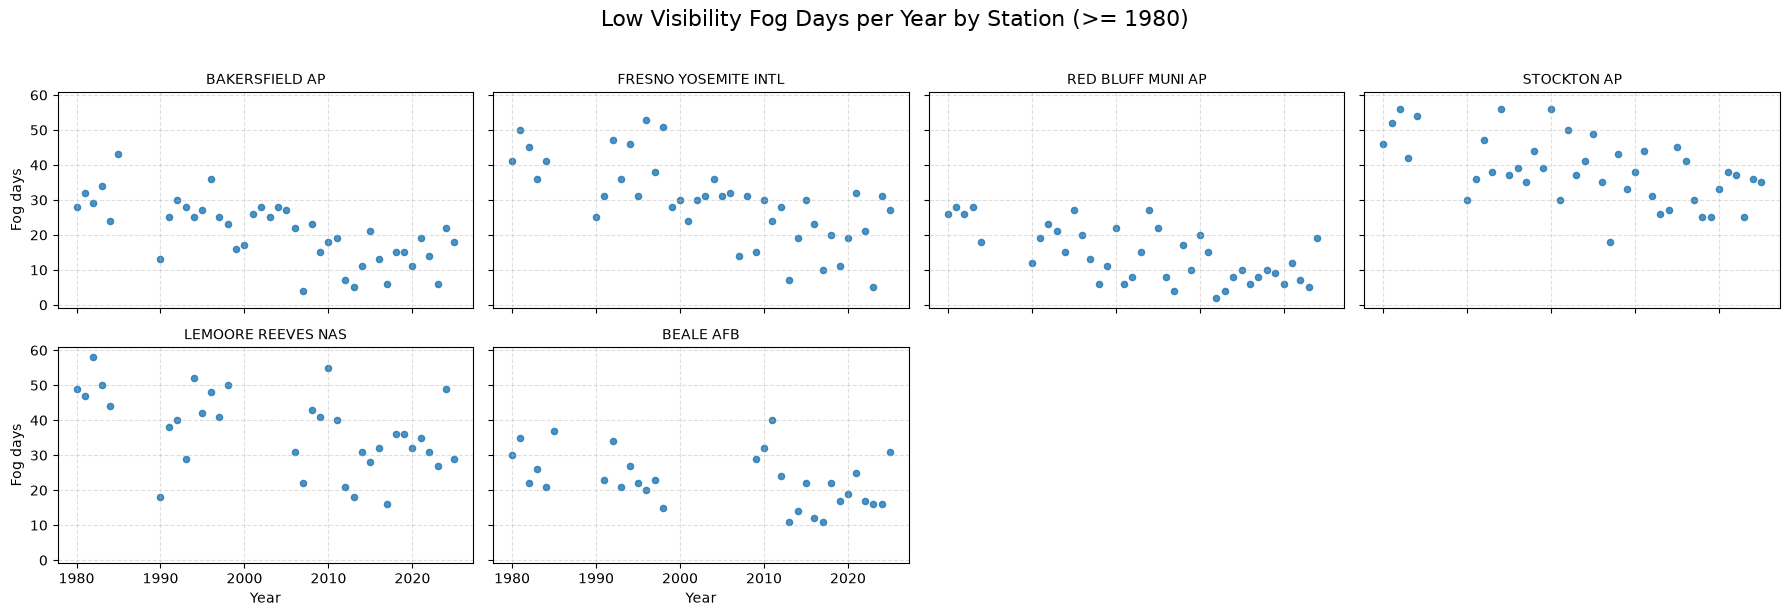

In [ ]:
stations = stations_significant_low_vis_post1980

plot_df = low_vis_fog_days_year_filtered[
    (low_vis_fog_days_year_filtered['STATION'].isin(stations)) &
    (low_vis_fog_days_year_filtered['year'] >= 1980)
].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df['STATION'] == station].sort_values('year')
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station (>= 1980)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

___________

In [289]:
# Filter for low visibility fog days before 1980
pre1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] < 1980].copy()

trend_stats_low_vis_pre1980 = []

for station, station_df in pre1980_low_vis.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_pre1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_pre1980 = pd.DataFrame(trend_stats_low_vis_pre1980).sort_values("p_value")

print("Pre-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_pre1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_pre1980 = trend_stats_low_vis_pre1980[trend_stats_low_vis_pre1980["trend_significant"]]
print(f"\nStations with significant pre-1980 low-visibility fog-day trends: {len(significant_low_vis_pre1980)}")
print(significant_low_vis_pre1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_pre1980 = (
    pre1980_low_vis
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_pre1980 = smf.ols("fog_days ~ year", data=annual_low_vis_pre1980).fit()

print("\nAnnual aggregated pre-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_pre1980.summary())

Pre-1980 low-visibility fog-day trend statistics by station:
                     STATION  n_obs  min_year  max_year     slope  slope_se  \
7         SACRAMENTO AP ASOS     42      1932      1979 -0.394092  0.127888   
1                  BEALE AFB     14      1960      1979 -0.826087  0.420149   
10               STOCKTON AP     16      1949      1979 -0.415430  0.246973   
0             BAKERSFIELD AP     42      1932      1979  0.120979  0.099823   
5                 MODESTO AP      3      1973      1979 -1.035714  0.680449   
9   SACRAMENTO MCCLELLAN AFB     33      1941      1979 -0.120436  0.170377   
4         LEMOORE REEVES NAS     14      1962      1978 -0.416187  0.650106   
11          TRAVIS FIELD AFB     29      1944      1979  0.137391  0.233729   
2                 CASTLE AFB     27      1944      1979  0.127820  0.236158   
8      SACRAMENTO MATHER AFB     30      1942      1979 -0.082340  0.185685   
6          RED BLUFF MUNI AP     29      1946      1979 -0.059574  0.1

In [301]:
stations_significant_low_vis_pre1980 = significant_low_vis_pre1980.loc[
    significant_low_vis_pre1980["trend_significant"], "STATION"
].tolist()

print("Significant pre-1980 low-visibility fog-day trend stations:")
print(stations_significant_low_vis_pre1980)

Significant pre-1980 low-visibility fog-day trend stations:
['SACRAMENTO AP ASOS']


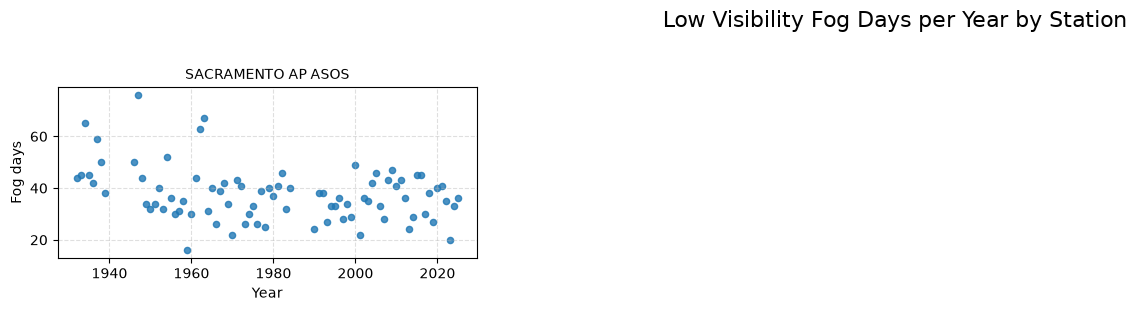

In [302]:
stations = stations_significant_low_vis_pre1980
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

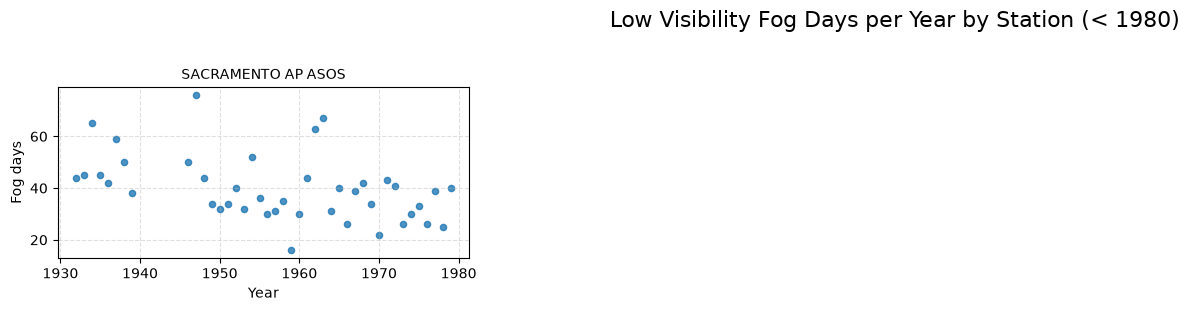

In [303]:
# stations = ['BAKERSFIELD AP', 'SACRAMENTO AP ASOS', 'STOCKTON AP','TRAVIS FIELD AFB','SACRAMENTO MATHER AFB','SACRAMENTO MCCLELLAN AFB','RED BLUFF MUNI AP','CASTLE AFB','FRESNO YOSEMITE INTL']
stations = stations_significant_low_vis_pre1980

plot_df = low_vis_fog_days_year_filtered[
    (low_vis_fog_days_year_filtered['STATION'].isin(stations)) &
    (low_vis_fog_days_year_filtered['year'] < 1980)
].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df['STATION'] == station].sort_values('year')
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station (< 1980)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

          STATION  year  fog_days  avg_event_duration_hours  total_events  \
0  BAKERSFIELD AP  1932        10                  2.400000            11   
1  BAKERSFIELD AP  1933        18                  2.261973            40   
2  BAKERSFIELD AP  1934        36                  2.530311            63   
3  BAKERSFIELD AP  1935        20                  2.317972            40   
4  BAKERSFIELD AP  1936        14                  2.676768            20   

   avg_monthly_low_vis_days  
0                  3.333333  
1                  6.000000  
2                  7.200000  
3                  5.000000  
4                  2.333333  


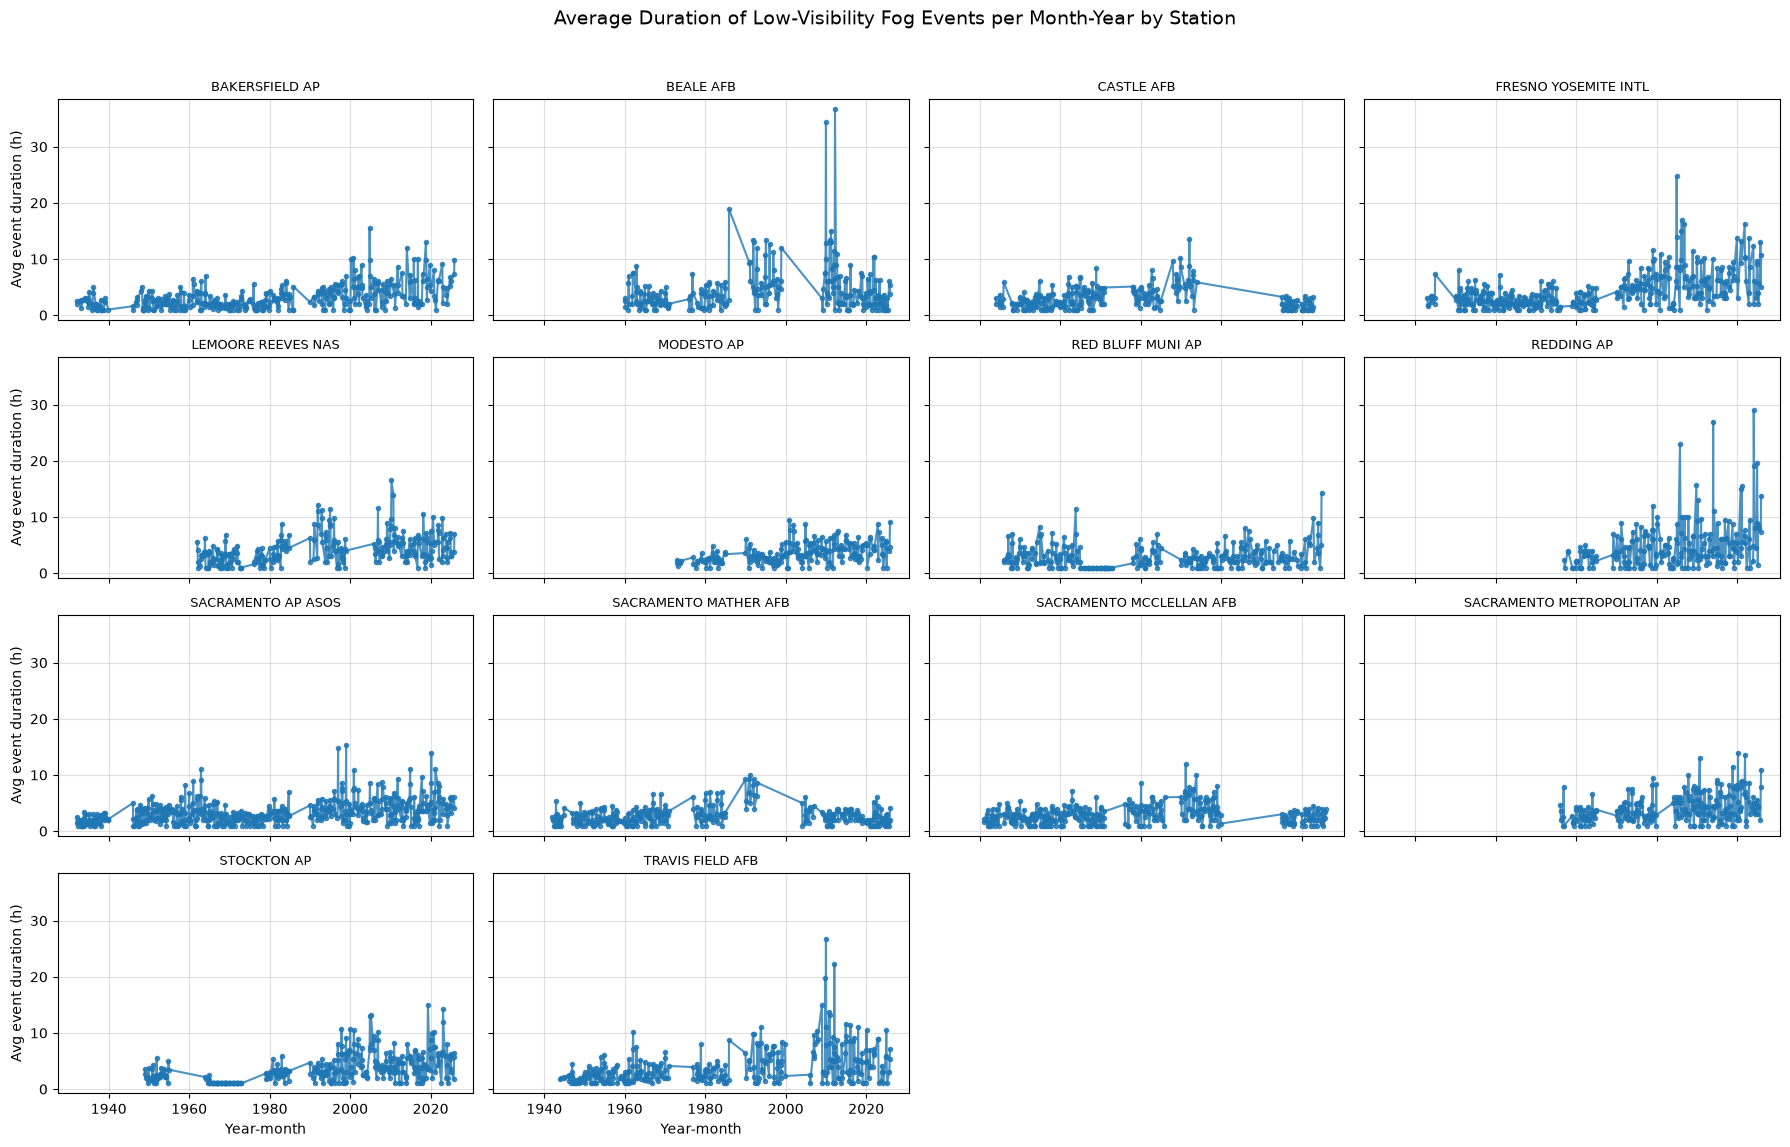

In [292]:
# compute low-visibility fog events from hourly CV_rows observations
low_vis_events = low_vis_rows.copy()
if low_vis_events["DATE"].dtype == object:
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"])

low_vis_events = low_vis_events.sort_values(["STATION", "DATE"])
# ensure DATE is datetime (handles object, pandas string dtype, etc.)
if not pd.api.types.is_datetime64_any_dtype(low_vis_events["DATE"]):
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"], errors="coerce")

# compute time difference within each station; treat first obs as a large gap
low_vis_events["time_diff"] = low_vis_events.groupby("STATION")["DATE"].diff()
low_vis_events["time_diff"] = low_vis_events["time_diff"].fillna(pd.Timedelta(hours=999))
low_vis_events["new_event"] = low_vis_events["time_diff"] > pd.Timedelta(hours=1.5)
low_vis_events["event_id"] = low_vis_events.groupby("STATION")["new_event"].cumsum()

event_summary = (
    low_vis_events
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(
        start=("DATE", "min"),
        end=("DATE", "max"),
        year=("year", "first"),
        month=("month", "first"),
        duration_hours=("event_id", "size"),
    )
)

event_summary["year_month"] = pd.to_datetime(
    dict(year=event_summary["year"], month=event_summary["month"], day=1)
)

monthly_low_vis_days = (
    low_vis_events
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "low_vis_days"})
)

event_monthly = (
    event_summary
    .groupby(["STATION", "year", "month"], as_index=False)
    .agg(
        avg_event_duration_hours=("duration_hours", "mean"),
        n_events=("duration_hours", "size"),
    )
    .merge(monthly_low_vis_days, on=["STATION", "year", "month"], how="left")
)

event_monthly["year_month"] = pd.to_datetime(
    dict(year=event_monthly["year"], month=event_monthly["month"], day=1)
)

annual_event_stats = (
    event_monthly
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        avg_event_duration_hours=("avg_event_duration_hours", "mean"),
        total_events=("n_events", "sum"),
        avg_monthly_low_vis_days=("low_vis_days", "mean"),
    )
)

annual_compare = low_vis_fog_days_year.merge(
    annual_event_stats,
    on=["STATION", "year"],
    how="left"
)

print(annual_compare.head())

plot_stations = stations_with_30_years.tolist()
n_stations = len(plot_stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(plot_stations):
    ax = axes[idx]
    station_df = event_monthly[event_monthly["STATION"] == station].sort_values("year_month")
    ax.plot(
        station_df["year_month"],
        station_df["avg_event_duration_hours"],
        marker="o",
        linestyle="-",
        markersize=3,
        alpha=0.8,
    )
    ax.set_title(station, fontsize=9)
    ax.grid(True, alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year-month")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Duration of Low-Visibility Fog Events per Month-Year by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


C:\Users\Work Account\AppData\Local\Temp\ipykernel_16440\3160788494.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


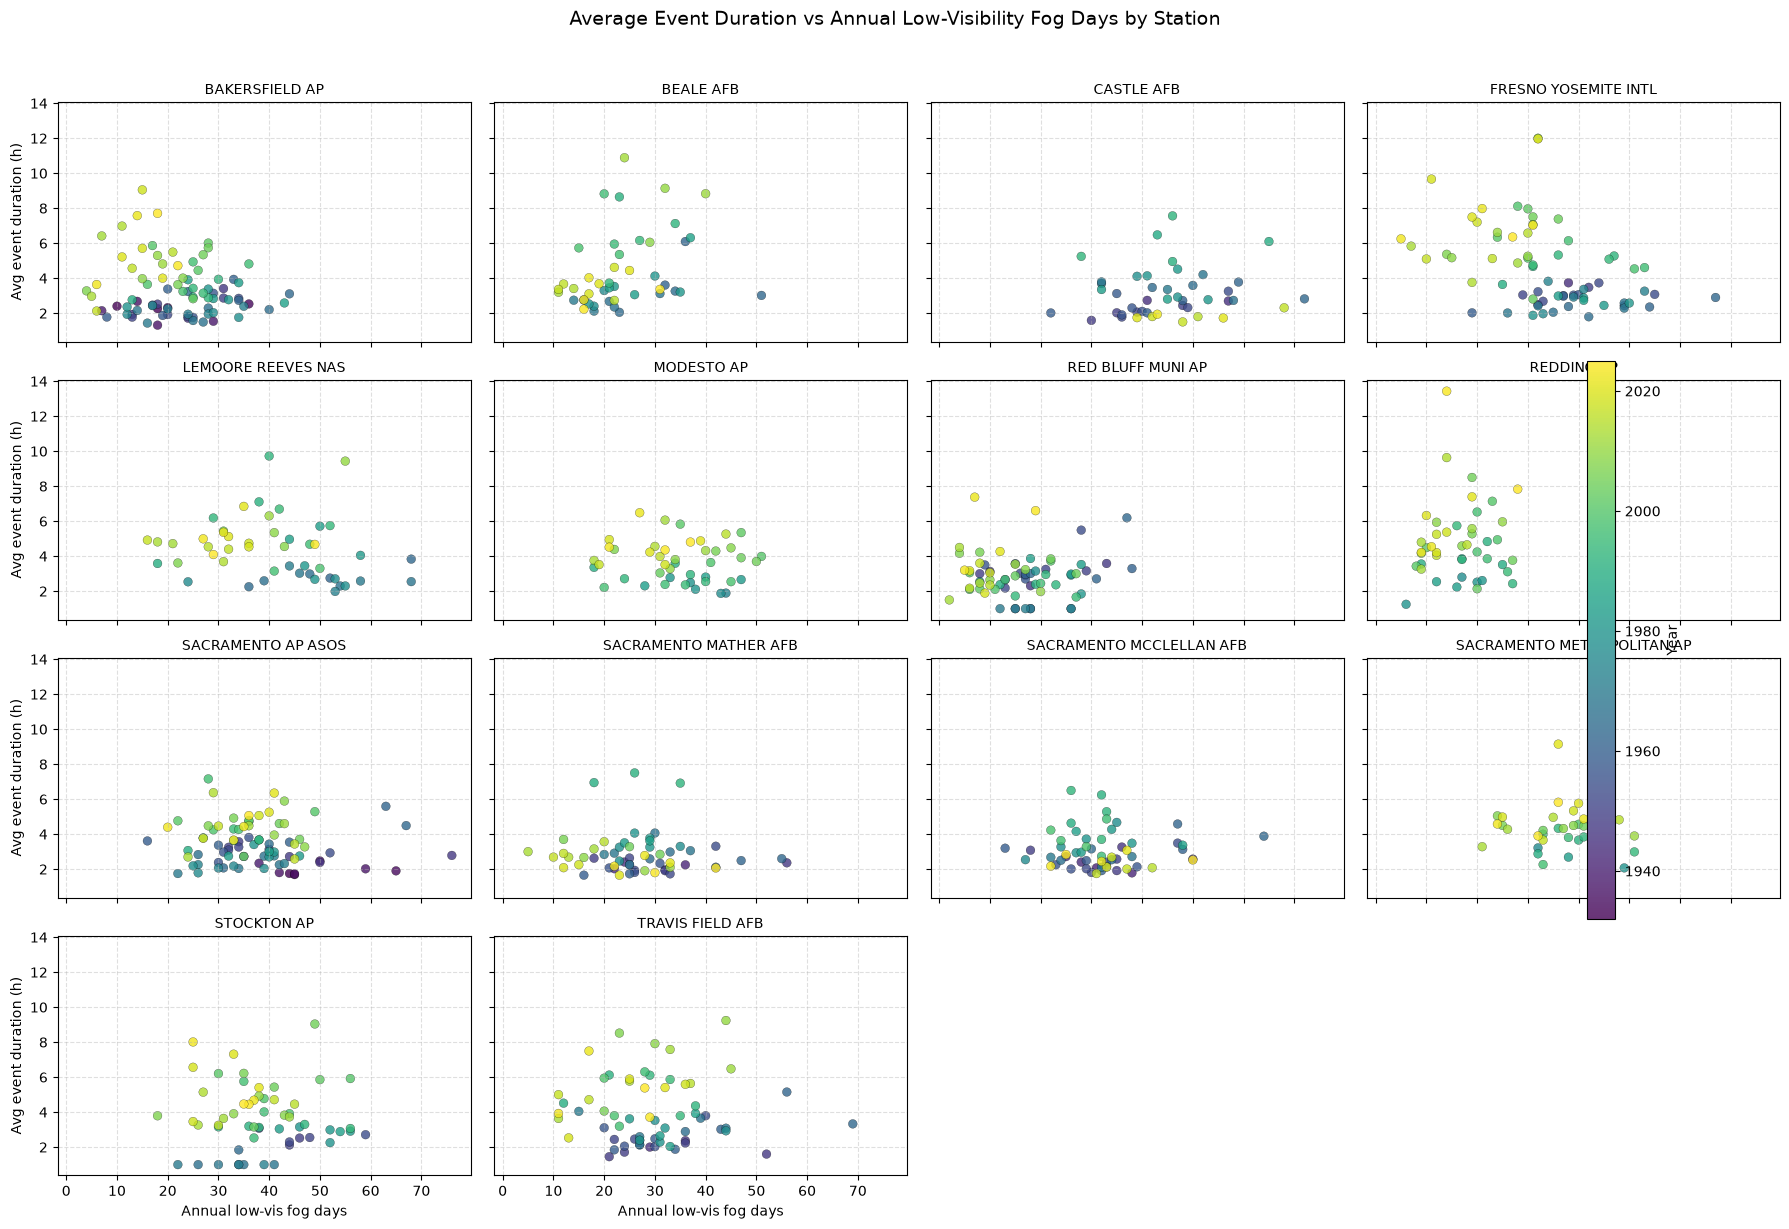

In [293]:
stations = stations_with_30_years.tolist()
plot_df = annual_compare[annual_compare["STATION"].isin(stations)].copy()

year_min = plot_df["year"].min()
year_max = plot_df["year"].max()
norm = plt.Normalize(year_min, year_max)
cmap = plt.cm.viridis

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

sc = None
for idx, station in enumerate(stations):
    ax = axes[idx]
    station_ann = plot_df[
        (plot_df["STATION"] == station) &
        plot_df["avg_event_duration_hours"].notna()
    ].sort_values("year")

    if station_ann.empty:
        ax.set_visible(False)
        continue

    sc = ax.scatter(
        station_ann["fog_days"],
        station_ann["avg_event_duration_hours"],
        c=station_ann["year"],
        cmap=cmap,
        norm=norm,
        s=40,
        alpha=0.8,
        edgecolor="k",
        linewidth=0.2,
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Annual low-vis fog days")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

if sc is not None:
    cbar = fig.colorbar(sc, ax=axes[:n_stations], orientation="vertical", fraction=0.02, pad=0.04)
    cbar.set_label("Year")

fig.suptitle("Average Event Duration vs Annual Low-Visibility Fog Days by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Monthly-event trend statistics by station (n_events ~ year + month):
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
5         FRESNO YOSEMITE INTL    379      1943      2025 -0.081136  0.012452   
7           LEMOORE REEVES NAS    255      1962      2025 -0.104410  0.019425   
14           RED BLUFF MUNI AP    280      1946      2024 -0.057145  0.014138   
6         HANFORD MUNICIPAL AP    135      2005      2025 -0.378509  0.105121   
19  SACRAMENTO METROPOLITAN AP    244      1976      2025 -0.085642  0.025471   
10   MARYSVILLE AIRPORT (ASOS)    105      2005      2025 -0.313305  0.095624   
21            TRAVIS FIELD AFB    322      1944      2025 -0.045181  0.014283   
16          SACRAMENTO AP ASOS    502      1932      2025 -0.026877  0.009663   
17       SACRAMENTO MATHER AFB    309      1942      2025 -0.030670  0.011905   
0               BAKERSFIELD AP    366      1932      2025 -0.029752  0.012621   
1                    BEALE AFB    240   

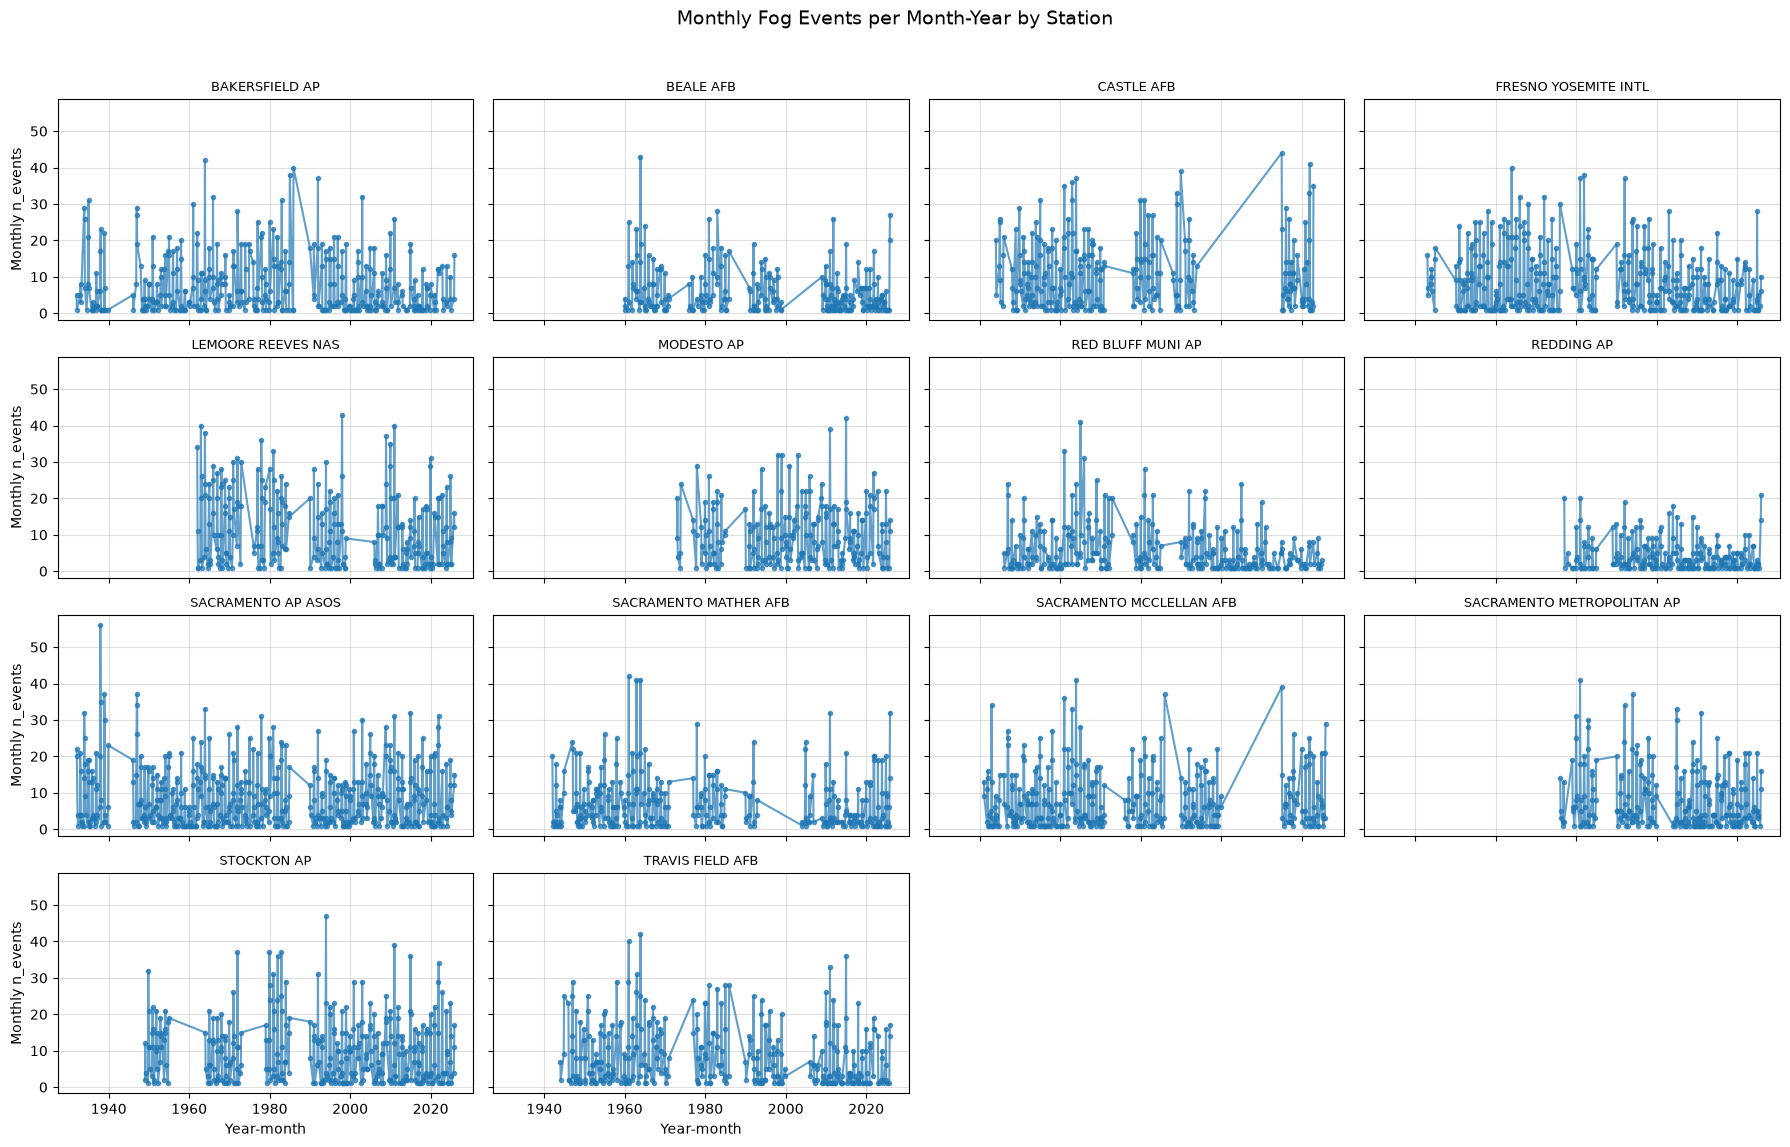

In [294]:
# Monthly-event analysis: trends of fog events per month-year by station

# use existing event_monthly (has n_events, avg_event_duration_hours, year, month, year_month)
events_monthly = event_monthly.copy()
events_monthly["year"] = events_monthly["year"].astype(int)

# station-level trends (model n_events ~ year + C(month) to account for seasonality)
trend_stats_events_monthly = []
for station, df in events_monthly.groupby("STATION"):
    df = df.sort_values("year_month")
    if len(df) < 36:  # require at least 3 years of monthly data
        continue
    model = smf.ols("n_events ~ year + C(month)", data=df).fit()
    trend_stats_events_monthly.append({
        "STATION": station,
        "n_obs": len(df),
        "min_year": df["year"].min(),
        "max_year": df["year"].max(),
        "slope": model.params.get("year", np.nan),
        "slope_se": model.bse.get("year", np.nan),
        "p_value": model.pvalues.get("year", np.nan),
        "r_squared": model.rsquared,
        "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
    })

trend_stats_events_monthly = pd.DataFrame(trend_stats_events_monthly).sort_values("p_value")
print("Monthly-event trend statistics by station (n_events ~ year + month):")
print(trend_stats_events_monthly.head(20))

significant_events_monthly = trend_stats_events_monthly[trend_stats_events_monthly["trend_significant"]]
print(f"\nStations with significant monthly-event trends: {len(significant_events_monthly)}")
print(significant_events_monthly[["STATION","n_obs","slope","p_value","r_squared"]])

# Post-1980 and Pre-1980 splits
events_post1980 = events_monthly[events_monthly["year"] >= 1980].copy()
events_pre1980 = events_monthly[events_monthly["year"] < 1980].copy()

def compute_trends(df):
    stats = []
    for station, g in df.groupby("STATION"):
        g = g.sort_values("year_month")
        if len(g) < 36:
            continue
        model = smf.ols("n_events ~ year + C(month)", data=g).fit()
        stats.append({
            "STATION": station,
            "n_obs": len(g),
            "min_year": g["year"].min(),
            "max_year": g["year"].max(),
            "slope": model.params.get("year", np.nan),
            "slope_se": model.bse.get("year", np.nan),
            "p_value": model.pvalues.get("year", np.nan),
            "r_squared": model.rsquared,
            "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
        })
    return pd.DataFrame(stats).sort_values("p_value")

trend_events_post1980 = compute_trends(events_post1980)
trend_events_pre1980 = compute_trends(events_pre1980)

print("\nPost-1980 monthly-event trends (top 20):")
print(trend_events_post1980.head(20)[["STATION","n_obs","slope","p_value","r_squared"]])

print("\nPre-1980 monthly-event trends (top 20):")
print(trend_events_pre1980.head(20)[["STATION","n_obs","slope","p_value","r_squared"]])

# Aggregate annual-seasonal diagnostics:
# annual sum of monthly events per station-year
annual_events = events_monthly.groupby(["STATION","year"], as_index=False)["n_events"].sum().rename(columns={"n_events":"annual_n_events"})
print("\nAnnual events (sample):")
print(annual_events.head())

# Plot: time series of monthly event counts for stations_with_30_years
plot_stations = stations_with_30_years.tolist()
n_stations = len(plot_stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(plot_stations):
    ax = axes[idx]
    sdf = events_monthly[events_monthly["STATION"] == station].sort_values("year_month")
    if sdf.empty:
        ax.set_visible(False)
        continue
    ax.plot(sdf["year_month"], sdf["n_events"], marker='o', linestyle='-', markersize=3, alpha=0.7)
    ax.set_title(station, fontsize=9)
    ax.grid(True, alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Monthly n_events")
    if idx >= (nrows-1)*ncols:
        ax.set_xlabel("Year-month")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Monthly Fog Events per Month-Year by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

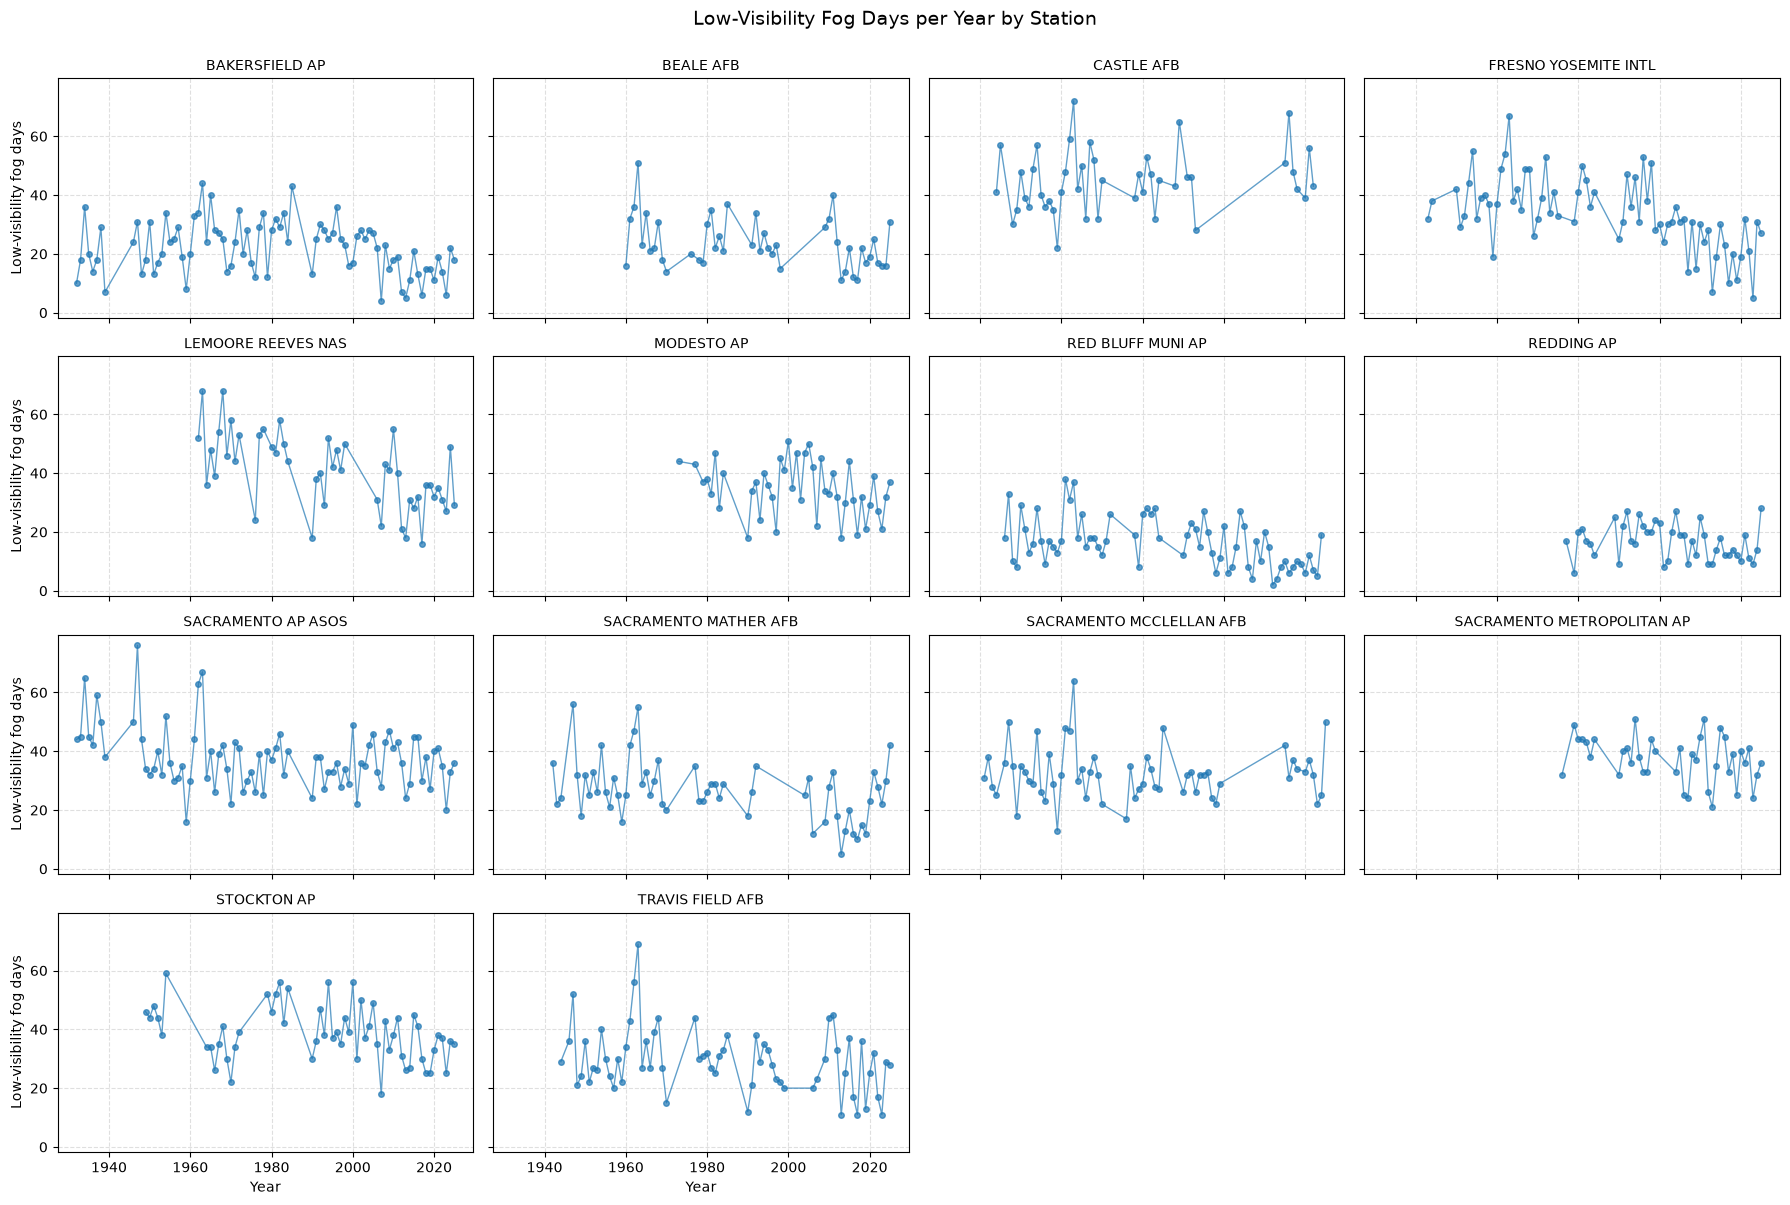

In [295]:
# Create a comprehensive plot of low-visibility fog days per station per year
stations = stations_with_30_years.tolist()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station].sort_values('year')
    ax.plot(station_df['year'], station_df['fog_days'], marker='o', linestyle='-', markersize=4, alpha=0.7, linewidth=1)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    if idx % ncols == 0:
        ax.set_ylabel('Low-visibility fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low-Visibility Fog Days per Year by Station', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()